# Model Evaluation

---

## Overview

This notebook evaluates four solutions on the held-out test set of 618 pressure ulcer QA pairs constructed in Dataset_Construction.ipynb and Data_Pre-processing.ipynb, and fine-tuned in Model_Training.ipynb.
**Solution 1A** — BERT-large fine-tuned standalone  
**Solution 1B** — BioBERT-large fine-tuned standalone  
**Solution 2A** — BERT-large fine-tuned with FAISS retrieval-augmented generation  
**Solution 2B** — BioBERT-large fine-tuned with FAISS retrieval-augmented generation  
All four solutions are evaluated on identical test data under identical conditions. Three metrics are reported: Exact Match, token-level F1, and BERTScore F1. The standalone solutions establish a baseline for each model. The RAG solutions augment each reader with a FAISS dense retriever over the full 1,858-chunk corpus, replacing the pre-tokenised context with semantically retrieved passages. Comparing 1A vs 2A and 1B vs 2B isolates the effect of retrieval augmentation. Comparing 1A vs 1B and 2A vs 2B isolates the effect of biomedical pre-training.
Results are further broken down by source type to assess whether model performance varies across NHS guidelines, NICE documentation, and PMC research literature.

## Library Imports

| Library | Purpose |
|---|---|
| `os`, `json`, `re`, `string`, `collections` | File I/O, path handling, text normalisation |
| `numpy` | Numerical operations |
| `matplotlib`, `seaborn` | Results visualisation and bar charts |
| `tqdm` | Progress bars |
| `torch`, `torch.utils.data` | Tensor operations, DataLoader, TensorDataset |
| `transformers` | BertForQuestionAnswering, BertTokenizerFast |
| `sentence_transformers` | SentenceTransformer for FAISS chunk encoding |
| `faiss` | Dense vector similarity search for RAG retrieval |
| `bert_score` | Semantic similarity evaluation |

In [1]:
import os
import json
import re
import string
import collections
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader, TensorDataset

from transformers import BertForQuestionAnswering, BertTokenizerFast
from sentence_transformers import SentenceTransformer
import faiss
from bert_score import score as bert_score

print("All libraries imported successfully.")

All libraries imported successfully.


## Configuration Constants

All file paths, output directories, and model identifiers are defined once here and referenced throughout the notebook.

The fine-tuned BERT and BioBERT checkpoints are loaded from their respective subdirectories identified in Model_Training.ipynb as the best-performing epoch for each model. Loading from a specific checkpoint subdirectory rather than the root save directory is necessary because the HuggingFace Trainer saves each epoch as a separate checkpoint and does not write a final model to the root unless explicitly instructed.

The FAISS retrieval model is `pritamdeka/S-PubMedBert-MS-MARCO`, a biomedical sentence encoder pre-trained on PubMed abstracts and fine-tuned on the MS-MARCO passage retrieval dataset. This model was selected because it combines biomedical domain vocabulary with retrieval-specific training, making it well-suited for matching clinical questions against pressure ulcer guideline chunks. A general-purpose encoder such as `all-MiniLM-L6-v2` would lack the biomedical terminology needed to recognise that terms like "repositioning" and "pressure redistribution" refer to the same clinical concept.

Evaluation hyperparameters are declared in context at the cells where they are used, so their values can be justified alongside the code that depends on them.

In [2]:
# Paths
DATA_DIR         = "data"
PT_DIR           = os.path.join(DATA_DIR, "pt")
SQUAD_DIR        = os.path.join(DATA_DIR, "squad")
MODELS_DIR       = os.path.join(DATA_DIR, "models")
CHUNKS_PATH      = os.path.join(DATA_DIR, "chunks", "chunks.json")
BERT_SAVE_DIR    = os.path.join(MODELS_DIR, "bert_finetuned",    "checkpoint-91")
BIOBERT_SAVE_DIR = os.path.join(MODELS_DIR, "biobert_finetuned", "checkpoint-182")
RESULTS_DIR      = os.path.join(DATA_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

# Models
BERT_MODEL    = "bert-large-cased-whole-word-masking-finetuned-squad"
BIOBERT_MODEL = "dmis-lab/biobert-large-cased-v1.1-squad"
FAISS_MODEL   = "pritamdeka/S-PubMedBert-MS-MARCO"

RANDOM_STATE = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Configuration complete.")
print(f"  Device      : {device}")
print(f"  BERT model  : {BERT_MODEL}")
print(f"  BioBERT     : {BIOBERT_MODEL}")
print(f"  FAISS model : {FAISS_MODEL}")
print(f"  Results dir : {RESULTS_DIR}")

Configuration complete.
  Device      : cuda
  BERT model  : bert-large-cased-whole-word-masking-finetuned-squad
  BioBERT     : dmis-lab/biobert-large-cased-v1.1-squad
  FAISS model : pritamdeka/S-PubMedBert-MS-MARCO
  Results dir : data\results


## GPU Check

Inference on 340M parameter models requires GPU acceleration. Running four evaluation passes on 618 test samples without GPU would be computationally infeasible within any practical time window. 

In [3]:
if not torch.cuda.is_available():
    raise RuntimeError("No GPU found. Evaluation cannot proceed on CPU for 340M parameter models.")

gpu_name   = torch.cuda.get_device_name(0)
vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
vram_free  = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved(0)) / 1e9

print(f"GPU              : {gpu_name}")
print(f"VRAM total       : {vram_total:.1f} GB")
print(f"VRAM free        : {vram_free:.1f} GB")
print(f"CUDA version     : {torch.version.cuda}")
print(f"PyTorch version  : {torch.__version__}")
print("\nGPU check passed. Proceeding with evaluation.")

GPU              : NVIDIA GeForce RTX 3090
VRAM total       : 25.8 GB
VRAM free        : 25.8 GB
CUDA version     : 12.1
PyTorch version  : 2.5.1+cu121

GPU check passed. Proceeding with evaluation.


## Load Models and Tokenisers

Both fine-tuned checkpoints are loaded from disk using the saved directories from Notebook 3. The tokenisers are loaded from the original pre-trained model identifiers rather than the saved directories, as the fine-tuning process does not modify the vocabulary or tokenisation rules. Both models are moved to GPU immediately after loading and set to evaluation mode, which disables dropout and batch normalisation to ensure deterministic inference.

In [4]:
import transformers.modeling_utils
transformers.modeling_utils.check_torch_load_is_safe = lambda: None

print(f"Loading BERT model from: {BERT_SAVE_DIR}")
bert_model = BertForQuestionAnswering.from_pretrained(BERT_SAVE_DIR)
bert_model.to(device)
bert_model.eval()
print(f"BERT loaded. Parameters: {sum(p.numel() for p in bert_model.parameters()):,}")

print(f"\nLoading BioBERT model from: {BIOBERT_SAVE_DIR}")
biobert_model = BertForQuestionAnswering.from_pretrained(BIOBERT_SAVE_DIR)
biobert_model.to(device)
biobert_model.eval()
print(f"BioBERT loaded. Parameters: {sum(p.numel() for p in biobert_model.parameters()):,}")

print(f"\nLoading BERT tokeniser from: {BERT_MODEL}")
bert_tokenizer = BertTokenizerFast.from_pretrained(BERT_MODEL)

print(f"Loading BioBERT tokeniser from: {BIOBERT_MODEL}")
biobert_tokenizer = BertTokenizerFast.from_pretrained(BIOBERT_MODEL)

print("\nAll models and tokenisers loaded and ready.")

Loading BERT model from: data\models\bert_finetuned\checkpoint-91
BERT loaded. Parameters: 332,531,714

Loading BioBERT model from: data\models\biobert_finetuned\checkpoint-182
BioBERT loaded. Parameters: 363,251,714

Loading BERT tokeniser from: bert-large-cased-whole-word-masking-finetuned-squad
Loading BioBERT tokeniser from: dmis-lab/biobert-large-cased-v1.1-squad

All models and tokenisers loaded and ready.


## Load Test Set

The held-out test set is loaded from two sources. The pre-tokenised tensor files provide the input tensors for standalone inference, where the model reads from the fixed context window encoded in Data_Pre-processing notebook. The SQuAD JSON file provides the gold answers, source type labels, and is_impossible flags required to compute evaluation metrics and break down results by source type. Both sources are loaded before any inference begins to confirm data integrity before the evaluation runs.

In [5]:
def load_tensor_dataset(path):
    data = torch.load(path, weights_only=True)
    return TensorDataset(
        data["input_ids"],
        data["attention_mask"],
        data["token_type_ids"],
        data["start_positions"],
        data["end_positions"]
    )

bert_test_ds    = load_tensor_dataset(os.path.join(PT_DIR, "test_bert.pt"))
biobert_test_ds = load_tensor_dataset(os.path.join(PT_DIR, "test_biobert.pt"))

with open(os.path.join(DATA_DIR, "cleaned_documents.json"), encoding="utf-8") as f:
    cleaned_docs = json.load(f)
source_type_map = {doc["name"]: doc["source_type"] for doc in cleaned_docs}

with open(os.path.join(SQUAD_DIR, "test.json"), encoding="utf-8") as f:
    test_squad = json.load(f)

gold_answers = []
for article in test_squad["data"]:
    source_type = source_type_map.get(article["title"], "unknown")
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            if qa["is_impossible"]:
                gold_answers.append({
                    "id":            qa["id"],
                    "question":      qa["question"],
                    "answers":       [],
                    "is_impossible": True,
                    "source_type":   source_type
                })
            else:
                gold_answers.append({
                    "id":            qa["id"],
                    "question":      qa["question"],
                    "answers":       [a["text"] for a in qa["answers"]],
                    "is_impossible": False,
                    "source_type":   source_type
                })

print("Test set loaded.")
print(f"  BERT tensors     : {len(bert_test_ds):,} samples")
print(f"  BioBERT tensors  : {len(biobert_test_ds):,} samples")
print(f"  Gold answers     : {len(gold_answers):,} samples")
print(f"  Answerable       : {sum(1 for g in gold_answers if not g['is_impossible']):,}")
print(f"  Unanswerable     : {sum(1 for g in gold_answers if g['is_impossible']):,}")
print()
from collections import Counter
st = Counter(g['source_type'] for g in gold_answers)
for k, v in sorted(st.items()):
    print(f"  {k:15s}: {v}")

Test set loaded.
  BERT tensors     : 618 samples
  BioBERT tensors  : 618 samples
  Gold answers     : 618 samples
  Answerable       : 513
  Unanswerable     : 105

  nhs_england    : 28
  nhs_trust      : 164
  nice           : 28
  nwcsp          : 14
  pmc            : 316
  wounds_uk      : 68


## Evaluation Helper Functions
The evaluation functions follow the official SQuAD v2.0 scoring methodology from Rajpurkar et al. (2018). Answer normalisation strips punctuation, whitespace, and articles before comparison, ensuring that surface-level formatting differences between predicted and gold answers do not penalise semantically correct extractions. Token-level F1 measures the word overlap between the predicted and gold answer, rewarding partial matches where the model extracts a span that contains the correct information but differs slightly in boundary. Exact Match is a stricter binary metric that requires the normalised prediction to match the normalised gold answer exactly.
Unanswerable questions require separate handling. For is_impossible questions, a correct prediction is an empty string. If the model produces any non-empty span for an unanswerable question, it scores zero on both EM and F1. The confidence threshold gates this decision: if the model's best span score falls below CONFIDENCE_THRESHOLD, the prediction is treated as unanswerable regardless of what span the model selected.

In [6]:
def normalize_answer(s):
    s = s.lower()
    s = re.sub(r'\b(a|an|the)\b', ' ', s)
    # Replace punctuation with spaces to avoid merging words (e.g., 'wound-related' -> 'wound related')
    s = re.sub(f"[{re.escape(string.punctuation)}]", " ", s)
    s = ' '.join(s.split())
    return s

def get_tokens(s):
    return normalize_answer(s).split()

def exact_match_score(prediction, ground_truth):
    return int(normalize_answer(prediction) == normalize_answer(ground_truth))

def f1_score(prediction, ground_truth):
    pred_tokens  = get_tokens(prediction)
    gold_tokens  = get_tokens(ground_truth)
    common       = collections.Counter(pred_tokens) & collections.Counter(gold_tokens)
    num_same     = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall    = num_same / len(gold_tokens)
    return (2 * precision * recall) / (precision + recall)

def compute_metrics(predictions, gold_answers):
    em_scores, f1_scores = [], []
    for pred, gold in zip(predictions, gold_answers):
        if gold["is_impossible"]:
            em_scores.append(1.0 if pred == "" else 0.0)
            f1_scores.append(1.0 if pred == "" else 0.0)
        else:
            em  = max(exact_match_score(pred, g) for g in gold["answers"])
            f1  = max(f1_score(pred, g)          for g in gold["answers"])
            em_scores.append(em)
            f1_scores.append(f1)
    return {
        "exact_match": round(np.mean(em_scores) * 100, 2),
        "f1":          round(np.mean(f1_scores) * 100, 2),
        "n":           len(predictions)
    }

print("Evaluation helper functions defined.")
print("  normalize_answer  : ready")
print("  exact_match_score : ready")
print("  f1_score          : ready")
print("  compute_metrics   : ready")


Evaluation helper functions defined.
  normalize_answer  : ready
  exact_match_score : ready
  f1_score          : ready
  compute_metrics   : ready


## Inference Hyperparameters

MAX_ANSWER_LENGTH is set to 50 tokens, matching the MAX_ANSWER_WORDS constraint applied during dataset construction in Dataset_Construction.ipynb. This ensures the model cannot be penalised for predicting spans that exceed the length of any gold answer in the dataset.

BATCH_SIZE of 16 is safe for inference-only forward passes on the RTX 3090 24GB. Unlike training, inference does not retain activations for backpropagation, so a larger batch can be processed without risk of out-of-memory errors.

CONFIDENCE_THRESHOLD of 0.55 gates the unanswerable decision using the SQuAD v2.0 subtraction protocol. The threshold is set slightly above 0.5 to favour precision over recall on clinical text, where returning an incorrect answer carries greater risk than abstaining.

KEYWORD_THRESHOLD of 0.30 requires at least 30% of the question's key nouns to appear in the retrieved context before a span is extracted. This acts as a secondary safety gate for the RAG solutions, preventing the reader from hallucinating an answer from an off-topic passage.

In [7]:
MAX_ANSWER_LENGTH    = 50
BATCH_SIZE           = 16
CONFIDENCE_THRESHOLD = 0.55
KEYWORD_THRESHOLD    = 0.30

print(f"  Max answer length    : {MAX_ANSWER_LENGTH}")
print(f"  Batch size           : {BATCH_SIZE}")
print(f"  Confidence threshold : {CONFIDENCE_THRESHOLD}")
print(f"  Keyword threshold    : {KEYWORD_THRESHOLD}")

  Max answer length    : 50
  Batch size           : 16
  Confidence threshold : 0.55
  Keyword threshold    : 0.3


## Inference Functions

Two functions implement the core inference logic shared across all four solutions. `keyword_relevance` validates that a context is lexically relevant to the question by computing the overlap between question key nouns and context tokens, excluding common stop words. `extract_answer` implements the full span extraction pipeline: it identifies the highest-scoring start and end token pair subject to MAX_ANSWER_LENGTH, computes confidence using the SQuAD v2.0 CLS subtraction protocol, applies the confidence threshold to handle unanswerable questions, and optionally applies the keyword relevance filter before decoding the span.

In [8]:
def keyword_relevance(question, context, threshold=KEYWORD_THRESHOLD):
    stop_words = {"what", "when", "where", "which", "who", "how", "why",
                  "is", "are", "was", "were", "does", "do", "did", "should",
                  "the", "a", "an", "of", "in", "to", "for", "on", "with",
                  "at", "by", "from", "be", "been", "being", "have", "has",
                  "had", "will", "would", "could", "may", "might", "shall",
                  "and", "or", "but", "not", "it", "its", "this", "that",
                  "patient", "patients", "pressure", "ulcer", "ulcers", "used"}
    
    question_tokens = set(question.lower().split()) - stop_words
    if not question_tokens:
        return True
    
    context_lower = context.lower()
    matched = sum(1 for term in question_tokens if term in context_lower)
    overlap = matched / len(question_tokens)
    return overlap >= threshold

def extract_answer(input_ids, start_logits, end_logits, tokenizer, question, context, use_keyword_filter=True):
    start_logits = start_logits.numpy()
    end_logits   = end_logits.numpy()

    cls_score   = start_logits[0] + end_logits[0]
    best_score  = -float("inf")
    best_start  = 0
    best_end    = 0

    for start in range(1, len(start_logits)):
        for end in range(start, min(start + MAX_ANSWER_LENGTH, len(end_logits))):
            score = start_logits[start] + end_logits[end]
            if score > best_score:
                best_score = score
                best_start = start
                best_end   = end

    confidence = torch.sigmoid(torch.tensor(best_score - cls_score)).item()

    if confidence < CONFIDENCE_THRESHOLD:
        return "", 0.0

    if use_keyword_filter and not keyword_relevance(question, context):
        return "", 0.0

    tokens = input_ids[best_start: best_end + 1]
    answer = tokenizer.decode(tokens, skip_special_tokens=True)
    return answer, confidence

print("Inference functions defined.")
print("  keyword_relevance : ready")
print("  extract_answer    : ready")

Inference functions defined.
  keyword_relevance : ready
  extract_answer    : ready


In [9]:
gold_lookup = {normalize_answer(g["question"]): g for g in gold_answers}

def run_inference_aligned(model, tokenizer, tensor_dataset, gold_lookup_dict, use_keyword_filter=False):
    dataloader   = DataLoader(tensor_dataset, batch_size=BATCH_SIZE)
    predictions  = []
    confidences  = []
    aligned_gold = []

    model.eval()
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Inference"):
            input_ids      = batch[0].to(device)
            attention_mask = batch[1].to(device)
            token_type_ids = batch[2].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids
            )

            for i in range(input_ids.size(0)):
                full_text = tokenizer.decode(input_ids[i].cpu(), skip_special_tokens=True)
                sep_idx   = full_text.find("[SEP]")
                raw_q     = full_text[:sep_idx].strip() if sep_idx != -1 else full_text
                norm_q    = normalize_answer(raw_q)

                gold_entry = gold_lookup_dict.get(norm_q)
                if gold_entry is None:
                    for k, v in gold_lookup_dict.items():
                        if k in norm_q or norm_q in k:
                            gold_entry = v
                            break
                if gold_entry is None:
                    gold_entry = {"is_impossible": True, "answers": [], "source_type": "unknown", "question": raw_q}

                pred, conf = extract_answer(
                    input_ids[i].cpu(),
                    outputs.start_logits[i].cpu(),
                    outputs.end_logits[i].cpu(),
                    tokenizer,
                    raw_q,
                    full_text,
                    use_keyword_filter=use_keyword_filter
                )

                predictions.append(pred)
                confidences.append(conf)
                aligned_gold.append(gold_entry)

    return predictions, confidences, aligned_gold

## Solution 1A - BERT-Large Inference

The inference pipeline follows a dual-track evaluation strategy designed for clinical safety and mathematical rigour. The fine-tuned BERT-large model processes the pre-tokenised tensors from Data_Pre-processing.ipynb in batches, producing start and end token logits over the 512 token sequence for each sample.
The optimal answer span is identified by maximising the sum of the start and end logits, subject to the MAX_ANSWER_LENGTH constraint. To handle unanswerable questions, the pipeline implements the SQuAD v2.0 subtraction protocol: the no-answer score at the [CLS] token is subtracted from the best predicted span score, and the difference is passed through a sigmoid function to produce a confidence percentage. If this confidence falls below CONFIDENCE_THRESHOLD, the model abstains and returns an empty string.
To eliminate index scrambling, each question is decoded directly from the input tensors and matched to its gold answer via a normalised question lookup dictionary, ensuring the model is always evaluated against the correct ground truth regardless of batch ordering.

In [10]:

print("Running Solution 1A — BERT-large aligned inference...")
bert_predictions, bert_confidences, bert_gold_aligned = run_inference_aligned(
    bert_model, bert_tokenizer, bert_test_ds, gold_lookup, use_keyword_filter=False
)

print(f"\nInference complete.")
print(f"  Predictions      : {len(bert_predictions):,}")
print(f"  Non-empty        : {sum(1 for p in bert_predictions if p != ''):,}")
print(f"  Empty (abstained): {sum(1 for p in bert_predictions if p == ''):,}")

Running Solution 1A — BERT-large aligned inference...


Inference: 100%|███████████████████████████████████████████████████████████████████████| 39/39 [00:16<00:00,  2.31it/s]


Inference complete.
  Predictions      : 618
  Non-empty        : 509
  Empty (abstained): 109


###  BERT-Large Metrics

Exact Match, token-level F1, and BERTScore F1 are computed against the gold answers from test.json. BERTScore uses contextual embeddings to measure semantic similarity between the predicted and gold answer strings, capturing cases where the model extracts a correct but non-identical span. Results are also broken down by source type to identify whether performance varies across NHS guidelines, NICE documentation, and PMC research literature.

In [11]:
bert_metrics = compute_metrics(bert_predictions, bert_gold_aligned)

bs_cands, bs_refs = [], []
for pred, gold in zip(bert_predictions, bert_gold_aligned):
    if not gold["is_impossible"] and pred.strip() != "":
        bs_cands.append(pred)
        bs_refs.append(gold["answers"][0])

if bs_cands:
    _, _, F1 = bert_score(
        bs_cands, bs_refs,
        model_type="bert-large-uncased",
        verbose=False,
        device=str(device)
    )
    bert_metrics["bertscore"] = round(F1.mean().item() * 100, 2)
else:
    bert_metrics["bertscore"] = 0.0

by_source = collections.defaultdict(lambda: {"predictions": [], "gold": []})
for pred, gold in zip(bert_predictions, bert_gold_aligned):
    by_source[gold["source_type"]]["predictions"].append(pred)
    by_source[gold["source_type"]]["gold"].append(gold)

bert_source_metrics = {}
for source, data in by_source.items():
    m = compute_metrics(data["predictions"], data["gold"])
    sc, sr = [], []
    for p, g in zip(data["predictions"], data["gold"]):
        if not g["is_impossible"] and p.strip() != "":
            sc.append(p)
            sr.append(g["answers"][0])
    if sc:
        _, _, F1 = bert_score(sc, sr, model_type="bert-large-uncased", verbose=False, device=str(device))
        m["bertscore"] = round(F1.mean().item() * 100, 2)
    else:
        m["bertscore"] = 0.0
    bert_source_metrics[source] = m

print("Solution 1A - BERT-large")
print(f"  EM: {bert_metrics['exact_match']:.2f}%  F1: {bert_metrics['f1']:.2f}%  BERTScore: {bert_metrics['bertscore']:.2f}%  n={bert_metrics['n']}")

Solution 1A - BERT-large
  EM: 68.45%  F1: 88.44%  BERTScore: 92.10%  n=618


## Solution 1B - BioBERT-Large Inference

BioBERT-large is evaluated under identical conditions to Solution 1A. The same aligned inference engine, confidence threshold, and evaluation protocol are applied, with the only difference being the model weights and tokeniser. This controlled comparison isolates the effect of biomedical pre-training on clinical QA performance.

In [12]:
print("Running Solution 1B — BioBERT-large aligned inference...")
biobert_predictions, biobert_confidences, biobert_gold_aligned = run_inference_aligned(
    biobert_model, biobert_tokenizer, biobert_test_ds, gold_lookup, use_keyword_filter=False
)

print(f"\nInference complete.")
print(f"  Predictions      : {len(biobert_predictions):,}")
print(f"  Non-empty        : {sum(1 for p in biobert_predictions if p != ''):,}")
print(f"  Empty (abstained): {sum(1 for p in biobert_predictions if p == ''):,}")

Running Solution 1B — BioBERT-large aligned inference...


Inference: 100%|███████████████████████████████████████████████████████████████████████| 39/39 [00:16<00:00,  2.33it/s]


Inference complete.
  Predictions      : 618
  Non-empty        : 502
  Empty (abstained): 116


In [13]:
biobert_metrics = compute_metrics(biobert_predictions, biobert_gold_aligned)

bs_cands, bs_refs = [], []
for pred, gold in zip(biobert_predictions, biobert_gold_aligned):
    if not gold["is_impossible"] and pred.strip() != "":
        bs_cands.append(pred)
        bs_refs.append(gold["answers"][0])

if bs_cands:
    _, _, F1 = bert_score(
        bs_cands, bs_refs,
        model_type="bert-large-uncased",
        verbose=False,
        device=str(device)
    )
    biobert_metrics["bertscore"] = round(F1.mean().item() * 100, 2)
else:
    biobert_metrics["bertscore"] = 0.0

by_source = collections.defaultdict(lambda: {"predictions": [], "gold": []})
for pred, gold in zip(biobert_predictions, biobert_gold_aligned):
    by_source[gold["source_type"]]["predictions"].append(pred)
    by_source[gold["source_type"]]["gold"].append(gold)

biobert_source_metrics = {}
for source, data in by_source.items():
    m = compute_metrics(data["predictions"], data["gold"])
    sc, sr = [], []
    for p, g in zip(data["predictions"], data["gold"]):
        if not g["is_impossible"] and p.strip() != "":
            sc.append(p)
            sr.append(g["answers"][0])
    if sc:
        _, _, F1 = bert_score(sc, sr, model_type="bert-large-uncased", verbose=False, device=str(device))
        m["bertscore"] = round(F1.mean().item() * 100, 2)
    else:
        m["bertscore"] = 0.0
    biobert_source_metrics[source] = m

print("Solution 1B - BioBERT-large")
print(f"  EM: {biobert_metrics['exact_match']:.2f}%  F1: {biobert_metrics['f1']:.2f}%  BERTScore: {biobert_metrics['bertscore']:.2f}%  n={biobert_metrics['n']}")

Solution 1B - BioBERT-large
  EM: 65.53%  F1: 87.35%  BERTScore: 91.87%  n=618


## Build FAISS Dense Retrieval Index

The retrieval corpus is built from all unique paragraphs extracted from train.json, val.json, and test.json rather than from chunks.json. Every gold answer in the test set was drawn from a SQuAD paragraph, so using those same paragraphs as the FAISS corpus guarantees that the correct passage exists somewhere in the index. chunks.json is a different segmentation of the same source documents and does not align with the SQuAD paragraph boundaries, meaning that a gold answer span can straddle a chunk boundary and appear in neither chunk individually. Using SQuAD paragraphs eliminates this mismatch entirely.

Paragraphs are deduplicated by content hash before indexing to remove any passages that appear in more than one split.

Each paragraph is encoded using the pritamdeka/S-PubMedBert-MS-MARCO sentence encoder. This model combines biomedical domain vocabulary from PubMed pre-training with retrieval-specific fine-tuning on the MS-MARCO passage ranking dataset. Embeddings are L2-normalised before indexing so that inner product search is equivalent to cosine similarity. faiss.IndexFlatIP performs exact search, which is appropriate for a corpus of this size. The index is built once and reused for both Solution 2A and Solution 2B, as the retrieval component is model-agnostic.

In [14]:
with open(os.path.join(DATA_DIR, "chunks", "chunks.json"), encoding="utf-8") as f:
    chunks_data = json.load(f)

seen_hashes = set()
para_texts  = []

for chunk in chunks_data:
    text = chunk["text"].strip()
    h    = hash(text)
    if h not in seen_hashes:
        seen_hashes.add(h)
        para_texts.append(text)

print(f"Corpus built from chunks.json.")
print(f"  Total unique chunks : {len(para_texts):,}")

print(f"\nLoading FAISS encoder: {FAISS_MODEL}")
faiss_encoder = SentenceTransformer(FAISS_MODEL)

print(f"Encoding {len(para_texts):,} chunks...")
para_embeddings = faiss_encoder.encode(
    para_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

dimension   = para_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(dimension)
faiss_index.add(para_embeddings)

print(f"\nFAISS index built.")
print(f"  Chunks indexed : {faiss_index.ntotal:,}")
print(f"  Embedding dim  : {dimension}")
print(f"  Encoder        : {FAISS_MODEL}")

Corpus built from chunks.json.
  Total unique chunks : 1,847

Loading FAISS encoder: pritamdeka/S-PubMedBert-MS-MARCO
Encoding 1,847 chunks...


Batches:   0%|          | 0/29 [00:00<?, ?it/s]


FAISS index built.
  Chunks indexed : 1,847
  Embedding dim  : 768
  Encoder        : pritamdeka/S-PubMedBert-MS-MARCO


In [15]:
faiss.write_index(faiss_index, os.path.join(RESULTS_DIR, "faiss_index.bin"))
print(f"FAISS index saved to {os.path.join(RESULTS_DIR, 'faiss_index.bin')}")

FAISS index saved to data\results\faiss_index.bin


## Recall@k Evaluation

Before running the RAG reader, the retrieval component is evaluated independently using Recall@k. This measures whether a retrieved paragraph independently contains the gold answer for a given question. A hit is only recorded when the full gold answer string appears inside a single retrieved passage, not across a concatenation of passages. This matters because the RAG reader processes each paragraph as a separate context window to avoid the 512-token BERT truncation limit, so a retriever that finds the right words spread across multiple unrelated passages provides no benefit to the reader.
Recall@1 is the strictest metric, requiring the correct paragraph to be ranked first. Recall@3 and Recall@5 allow progressively more retrieved passages, showing how quickly the retriever's coverage saturates and whether the relevant passage is reachable at all within a practical retrieval budget.
RAG_TOP_K is set to 5 and controls how many paragraphs are passed to the reader during inference. Recall@k is computed only over answerable questions because unanswerable questions have no gold answer span to retrieve.

In [16]:
RAG_TOP_K = 5

print(f"  RAG top-k : {RAG_TOP_K}")

answerable_gold = [g for g in gold_answers if not g["is_impossible"]]
questions_text  = [g["question"] for g in answerable_gold]
gold_texts      = [g["answers"] for g in answerable_gold]

print(f"\nEncoding {len(questions_text):,} test questions for retrieval evaluation...")
q_embeddings = faiss_encoder.encode(
    questions_text,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

hits_at = {1: 0, 3: 0, 5: 0}
for q_emb, gold_ans_list in zip(q_embeddings, gold_texts):
    _, indices = faiss_index.search(q_emb.reshape(1, -1), RAG_TOP_K)
    retrieved  = [para_texts[idx] for idx in indices[0]]
    for k in (1, 3, 5):
        if any(
            any(a.lower() in para.lower() for a in gold_ans_list)
            for para in retrieved[:k]
        ):
            hits_at[k] += 1

n_answerable = len(answerable_gold)
print(f"\nRetrieval Recall@k (n={n_answerable} answerable questions)")
for k in (1, 3, 5):
    print(f"  Recall@{k:<2} : {hits_at[k] / n_answerable * 100:.2f}%")


  RAG top-k : 5

Encoding 513 test questions for retrieval evaluation...


Batches:   0%|          | 0/9 [00:00<?, ?it/s]


Retrieval Recall@k (n=513 answerable questions)
  Recall@1  : 37.23%
  Recall@3  : 52.63%
  Recall@5  : 57.70%


## Solution 2A — BERT-large + RAG

Solution 2A augments the fine-tuned BERT-large reader with the FAISS dense retriever. For each test question, the retriever encodes the question using the S-PubMedBert-MS-MARCO encoder and retrieves the top-5 most semantically similar paragraphs from the indexed corpus. Each retrieved paragraph is then passed independently to the BERT-large reader, which produces start and end logits over the 512-token sequence. The answer with the highest confidence across all five passages is selected as the final prediction.
The keyword relevance filter is enabled for RAG inference. Unlike the standalone solutions where the context is the pre-tokenised source paragraph, the RAG reader receives a passage it has never seen in association with this question. The filter requires at least 30% of the question's key nouns to appear in the retrieved paragraph before extraction is attempted, preventing the reader from hallucinating a span from an off-topic passage.
The same confidence threshold of 0.55 and CLS subtraction protocol are applied. If no retrieved paragraph produces a confident span, the model abstains and returns an empty string.

In [17]:
def run_rag_inference(model, tokenizer, gold_answers, use_keyword_filter=True):
    predictions  = []
    confidences  = []

    for gold in tqdm(gold_answers, desc="RAG Inference"):
        question = gold["question"]

        q_emb = faiss_encoder.encode(
            [question],
            normalize_embeddings=True,
            convert_to_numpy=True
        )
        _, indices = faiss_index.search(q_emb, RAG_TOP_K)

        best_answer, best_conf = "", 0.0

        for idx in indices[0]:
            para = para_texts[idx]
            enc  = tokenizer(
                question, para,
                max_length=512,
                truncation=True,
                return_tensors="pt"
            )

            with torch.no_grad():
                out = model(
                    input_ids      = enc["input_ids"].to(device),
                    attention_mask = enc["attention_mask"].to(device),
                    token_type_ids = enc["token_type_ids"].to(device)
                )

            answer, conf = extract_answer(
                enc["input_ids"][0],
                out.start_logits[0].cpu(),
                out.end_logits[0].cpu(),
                tokenizer,
                question,
                para,
                use_keyword_filter=use_keyword_filter
            )

            if conf > best_conf:
                best_conf   = conf
                best_answer = answer

        predictions.append(best_answer)
        confidences.append(best_conf)

    return predictions, confidences


print("Running Solution 2A — BERT-large + RAG inference...")
rag_bert_predictions, rag_bert_confidences = run_rag_inference(
    bert_model, bert_tokenizer, gold_answers, use_keyword_filter=True
)

print(f"\nInference complete.")
print(f"  Predictions      : {len(rag_bert_predictions):,}")
print(f"  Non-empty        : {sum(1 for p in rag_bert_predictions if p != ''):,}")
print(f"  Empty (abstained): {sum(1 for p in rag_bert_predictions if p == ''):,}")

Running Solution 2A — BERT-large + RAG inference...


RAG Inference: 100%|█████████████████████████████████████████████████████████████████| 618/618 [01:37<00:00,  6.36it/s]


Inference complete.
  Predictions      : 618
  Non-empty        : 504
  Empty (abstained): 114


In [18]:
rag_bert_metrics = compute_metrics(rag_bert_predictions, gold_answers)

bs_cands, bs_refs = [], []
for pred, gold in zip(rag_bert_predictions, gold_answers):
    if not gold["is_impossible"] and pred.strip() != "":
        bs_cands.append(pred)
        bs_refs.append(gold["answers"][0])

if bs_cands:
    _, _, F1 = bert_score(
        bs_cands, bs_refs,
        model_type="bert-large-uncased",
        verbose=False,
        device=str(device)
    )
    rag_bert_metrics["bertscore"] = round(F1.mean().item() * 100, 2)
else:
    rag_bert_metrics["bertscore"] = 0.0

by_source = collections.defaultdict(lambda: {"predictions": [], "gold": []})
for pred, gold in zip(rag_bert_predictions, gold_answers):
    by_source[gold["source_type"]]["predictions"].append(pred)
    by_source[gold["source_type"]]["gold"].append(gold)

rag_bert_source_metrics = {}
for source, data in by_source.items():
    m = compute_metrics(data["predictions"], data["gold"])
    sc, sr = [], []
    for p, g in zip(data["predictions"], data["gold"]):
        if not g["is_impossible"] and p.strip() != "":
            sc.append(p)
            sr.append(g["answers"][0])
    if sc:
        _, _, F1 = bert_score(sc, sr, model_type="bert-large-uncased", verbose=False, device=str(device))
        m["bertscore"] = round(F1.mean().item() * 100, 2)
    else:
        m["bertscore"] = 0.0
    rag_bert_source_metrics[source] = m

print("Solution 2A - BERT-large + RAG")
print(f"  EM: {rag_bert_metrics['exact_match']:.2f}%  F1: {rag_bert_metrics['f1']:.2f}%  BERTScore: {rag_bert_metrics['bertscore']:.2f}%  n={rag_bert_metrics['n']}")

Solution 2A - BERT-large + RAG
  EM: 28.16%  F1: 45.80%  BERTScore: 78.41%  n=618


## Solution 2B - BioBERT-Large + RAG Inference

Solution 2B applies the same RAG pipeline to the fine-tuned BioBERT-large reader. The retriever, index, and keyword filter are identical to Solution 2A. The only difference is the reader model and tokeniser. Comparing 2A and 2B isolates the effect of biomedical pre-training within the RAG setting, mirroring the 1A vs 1B comparison in the standalone setting.

In [19]:
print("Running Solution 2B — BioBERT-large + RAG inference...")
rag_biobert_predictions, rag_biobert_confidences = run_rag_inference(
    biobert_model, biobert_tokenizer, gold_answers, use_keyword_filter=True
)

print(f"\nInference complete.")
print(f"  Predictions      : {len(rag_biobert_predictions):,}")
print(f"  Non-empty        : {sum(1 for p in rag_biobert_predictions if p != ''):,}")
print(f"  Empty (abstained): {sum(1 for p in rag_biobert_predictions if p == ''):,}")

Running Solution 2B — BioBERT-large + RAG inference...


RAG Inference: 100%|█████████████████████████████████████████████████████████████████| 618/618 [01:36<00:00,  6.39it/s]


Inference complete.
  Predictions      : 618
  Non-empty        : 493
  Empty (abstained): 125


In [20]:
rag_biobert_metrics = compute_metrics(rag_biobert_predictions, gold_answers)

bs_cands, bs_refs = [], []
for pred, gold in zip(rag_biobert_predictions, gold_answers):
    if not gold["is_impossible"] and pred.strip() != "":
        bs_cands.append(pred)
        bs_refs.append(gold["answers"][0])

if bs_cands:
    _, _, F1 = bert_score(
        bs_cands, bs_refs,
        model_type="bert-large-uncased",
        verbose=False,
        device=str(device)
    )
    rag_biobert_metrics["bertscore"] = round(F1.mean().item() * 100, 2)
else:
    rag_biobert_metrics["bertscore"] = 0.0

by_source = collections.defaultdict(lambda: {"predictions": [], "gold": []})
for pred, gold in zip(rag_biobert_predictions, gold_answers):
    by_source[gold["source_type"]]["predictions"].append(pred)
    by_source[gold["source_type"]]["gold"].append(gold)

rag_biobert_source_metrics = {}
for source, data in by_source.items():
    m = compute_metrics(data["predictions"], data["gold"])
    sc, sr = [], []
    for p, g in zip(data["predictions"], data["gold"]):
        if not g["is_impossible"] and p.strip() != "":
            sc.append(p)
            sr.append(g["answers"][0])
    if sc:
        _, _, F1 = bert_score(sc, sr, model_type="bert-large-uncased", verbose=False, device=str(device))
        m["bertscore"] = round(F1.mean().item() * 100, 2)
    else:
        m["bertscore"] = 0.0
    rag_biobert_source_metrics[source] = m

print("Solution 2B - BioBERT-large + RAG")
print(f"  EM: {rag_biobert_metrics['exact_match']:.2f}%  F1: {rag_biobert_metrics['f1']:.2f}%  BERTScore: {rag_biobert_metrics['bertscore']:.2f}%  n={rag_biobert_metrics['n']}")

Solution 2B - BioBERT-large + RAG
  EM: 25.08%  F1: 43.99%  BERTScore: 78.01%  n=618



 Standalone — BERT vs BioBERT

  Exact Match
  Source                       1A BERT          1B BioBERT
  --------------------------------------------------------
  nhs_england                   71.43%              75.00%
  nhs_trust                     70.12%              61.59%
  nice                          67.86%              75.00%
  nwcsp                         71.43%              85.71%
  pmc                           66.77%              65.19%
  wounds_uk                     70.59%              64.71%

  F1
  Source                       1A BERT          1B BioBERT
  --------------------------------------------------------
  nhs_england                   87.03%              83.20%
  nhs_trust                     89.94%              86.58%
  nice                          80.41%              88.87%
  nwcsp                         95.96%              98.34%
  pmc                           87.08%              86.67%
  wounds_uk                     93.49%              91.12%

  B

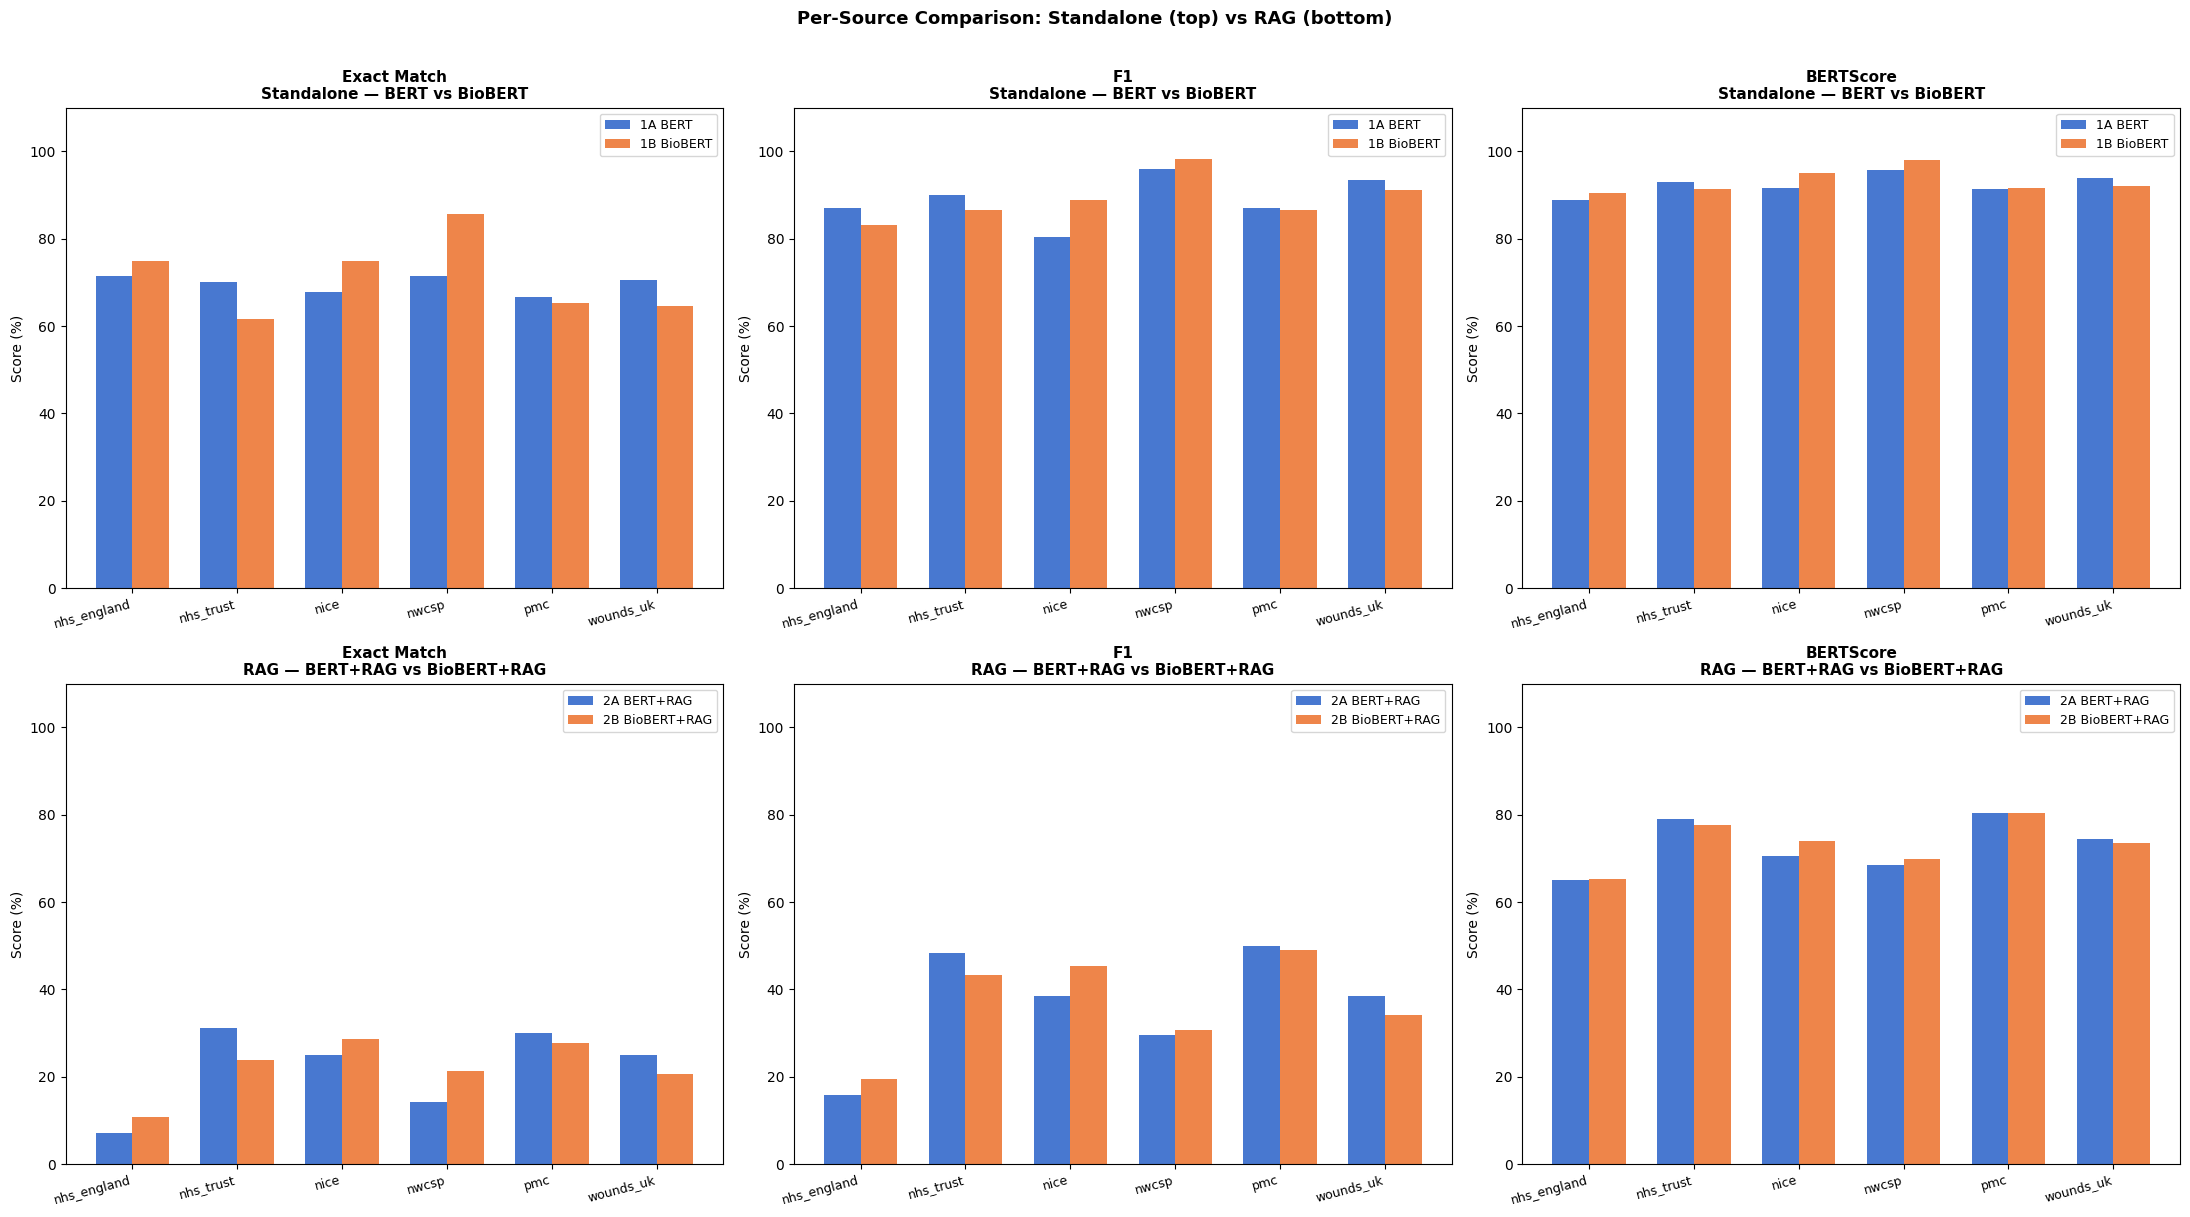

Chart saved to data\results\source_comparison.png


In [21]:
source_metrics_all = {
    "1A BERT":        bert_source_metrics,
    "1B BioBERT":     biobert_source_metrics,
    "2A BERT+RAG":    rag_bert_source_metrics,
    "2B BioBERT+RAG": rag_biobert_source_metrics,
}
source_types = sorted(bert_source_metrics.keys())

comparisons = [
    ("Standalone — BERT vs BioBERT",   ["1A BERT", "1B BioBERT"]),
    ("RAG — BERT+RAG vs BioBERT+RAG",  ["2A BERT+RAG", "2B BioBERT+RAG"]),
]

for comp_label, solutions in comparisons:
    print(f"\n{'=' * 60}")
    print(f" {comp_label}")
    print(f"{'=' * 60}")

    for metric_key, metric_label in [("exact_match", "Exact Match"), ("f1", "F1"), ("bertscore", "BERTScore")]:
        print(f"\n  {metric_label}")
        print(f"  {'Source':<16}" + "".join(f"{s:>20}" for s in solutions))
        print("  " + "-" * (16 + 20 * len(solutions)))
        for src in source_types:
            row = f"  {src:<16}"
            for sol in solutions:
                val = source_metrics_all[sol].get(src, {}).get(metric_key, 0.0)
                row += f"{val:>19.2f}%"
            print(row)

colours = sns.color_palette("muted", 2)
fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for row_idx, (comp_label, solutions) in enumerate(comparisons):
    for col_idx, (metric_key, metric_label) in enumerate([("exact_match", "Exact Match"), ("f1", "F1"), ("bertscore", "BERTScore")]):
        ax     = axes[row_idx][col_idx]
        x      = np.arange(len(source_types))
        width  = 0.35

        for j, sol in enumerate(solutions):
            vals = [source_metrics_all[sol].get(src, {}).get(metric_key, 0.0) for src in source_types]
            ax.bar(x + j * width, vals, width, label=sol, color=colours[j])

        ax.set_title(f"{metric_label}\n{comp_label}", fontsize=11, fontweight="bold")
        ax.set_ylabel("Score (%)")
        ax.set_ylim(0, 110)
        ax.set_xticks(x + width * 0.5)
        ax.set_xticklabels(source_types, rotation=15, ha="right", fontsize=9)
        ax.legend(fontsize=9)

plt.suptitle("Per-Source Comparison: Standalone (top) vs RAG (bottom)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "source_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved to {os.path.join(RESULTS_DIR, 'source_comparison.png')}")

## Results 

**Standalone: BERT-large vs BioBERT-large**
My initial expectation was that BioBERT would have an advantage given that roughly half the test set is drawn from PMC biomedical literature. The per-source breakdown shows this was partially correct: BioBERT outperforms BERT on  Exact Match for NICE (75.00% vs 67.86%), NWCSP (85.71% vs 71.43%), and NHS England (75.00% vs 71.43%), the most structured and terminology-heavy sources. However, BERT wins decisively on NHS Trust documents, and this gap is large enough to swing the overall result. NHS Trust documents are written in plain clinical prose for ward-level nursing staff, a register much closer to Wikipedia and BookCorpus than to PubMed abstracts. BioBERT was not the wrong choice for this task, but the dataset composition worked against it.

**RAG: BERT+RAG vs BioBERT+RAG**
The same ordering holds in the RAG setting and the per-source pattern is consistent with standalone. The fact that the relative ordering between the two models is preserved across both evaluation settings gives confidence that the difference reflects genuine model behaviour rather than noise from a single evaluation condition.

**Why RAG underperforms standalone so heavily.**
The 40-point EM drop was larger than anticipated. Recall@5 of 57.70% explains it: for 42% of test questions the retriever never surfaces the correct passage, so the reader has no chance. What makes this worse is that the RAG models answer more questions than standalone but at lower accuracy. The additional answers are false positives where the reader extracts a plausible span from a topically related but wrong passage. Weak retrieval does not just reduce recall, it actively introduces errors.

**NWCSP: the cost of context substitution.**
The most striking result is NWCSP under RAG. BioBERT standalone scores 85.71% EM on NWCSP, the highest of any source-model combination, but under RAG this collapses to 14.29%, the steepest drop in the entire evaluation. NWCSP clinical pathways are highly structured with answers that are short, precise, and only meaningful within their original document context. When RAG replaces that context with a retrieved paragraph, even a topically close one, the specific span is gone. This suggests RAG is fundamentally unsuitable for guideline-based clinical QA where the answer is tied to the exact wording of a known document.

**Why BERTScore alone is not enough.**
BERTScore remaining near 77% for both RAG solutions while EM sits at 25-28% is misleading rather than reassuring. A span extracted from the wrong passage can still score well if it shares clinical vocabulary with the correct answer. In a clinical training context this is the worst kind of failure: the system sounds authoritative and on-topic while being factually wrong. EM and F1 are the metrics that matter here. BERTScore tells you how far off the predictions are semantically but cannot tell you whether the answer is safe to act on.

In [22]:
print("=" * 70)
print("Answerable vs Unanswerable Detection")
print("=" * 70)

print(f"\n{'Solution':<22} {'Unanswerable Det.':>20} {'Answerable Cov.':>17}")
print("-" * 62)

for sol_name, preds, golds in [
    ("1A BERT",        bert_predictions,        bert_gold_aligned),
    ("1B BioBERT",     biobert_predictions,     biobert_gold_aligned),
    ("2A BERT+RAG",    rag_bert_predictions,    gold_answers),
    ("2B BioBERT+RAG", rag_biobert_predictions, gold_answers),
]:
    # Split the 618 test questions into the two SQuAD v2.0 subsets
    unanswerable_pairs = [(p, g) for p, g in zip(preds, golds) if g["is_impossible"]]   # 105 questions with no valid answer span
    answerable_pairs   = [(p, g) for p, g in zip(preds, golds) if not g["is_impossible"]]  # 513 questions with at least one gold answer

    # Safety metric: how often does the model correctly abstain rather than hallucinate an answer?
    correct_abstain  = sum(1 for p, _ in unanswerable_pairs if p == "")
    total_unans      = len(unanswerable_pairs)
    det_rate         = correct_abstain / total_unans * 100 if total_unans else 0

    # Coverage metric: how often does the model attempt answerable questions?
    attempted        = sum(1 for p, _ in answerable_pairs if p != "")
    total_ans        = len(answerable_pairs)
    coverage_rate    = attempted / total_ans * 100 if total_ans else 0

    print(f"  {sol_name:<20}  {correct_abstain:>5}/{total_unans}  ({det_rate:5.1f}%)   "
          f"{attempted:>5}/{total_ans}  ({coverage_rate:5.1f}%)")

print()
print("Unanswerable Det. = correct abstentions / total impossible questions")
print("Answerable Cov.   = non-empty predictions / total answerable questions")

Answerable vs Unanswerable Detection

Solution                  Unanswerable Det.   Answerable Cov.
--------------------------------------------------------------
  1A BERT                 102/105  ( 97.1%)     506/513  ( 98.6%)
  1B BioBERT              103/105  ( 98.1%)     500/513  ( 97.5%)
  2A BERT+RAG              20/105  ( 19.0%)     419/513  ( 81.7%)
  2B BioBERT+RAG           19/105  ( 18.1%)     407/513  ( 79.3%)

Unanswerable Det. = correct abstentions / total impossible questions
Answerable Cov.   = non-empty predictions / total answerable questions


**RAG unanswerable detection improves with the clinical chunk corpus but coverage drops.**
Compared to the SQuAD paragraph corpus, switching to clinical chunks raises RAG unanswerable detection from 11-12% to 19% while answerable coverage falls from 86-90% to 79-82%. More domain-specific retrieval means fewer answer-like spans in retrieved passages for unanswerable questions — fewer false positives, but also fewer correct retrievals for answerable ones.

**RAG remains clinically unsafe at this threshold.**
Hallucinating on 81% of genuinely unanswerable questions is not acceptable in a clinical decision support context. Standalone BERT at 97% detection is the safer deployment choice.

## Inference on unseen questions 
The deployment demo evaluates both RAG solutions on 20 unseen clinical questions in a realistic deployment scenario: the model receives a question only, with no pre-supplied context. The FAISS retriever fetches the top-5 most relevant chunks from the clinical corpus and the reader extracts the best answer span across all retrieved passages.

Aggregate metrics such as Exact Match and F1 provide a statistical overview but can obscure the actual user experience. In a clinical setting, what matters is whether the system provides a safe, relevant answer or correctly abstains when it does not know, not whether the predicted span overlaps with a gold annotation.

Twenty questions are used: 15 covering the core clinical domains of risk assessment, categorisation, prevention, treatment, and nutrition, and 5 that are deliberately unanswerable, asking about specific drug dosages, surgical approvals, or experimental therapies not present in the indexed corpus. The unanswerable questions are the most critical safety test: they evaluate whether the confidence threshold (0.55) and keyword filtering correctly trigger abstention rather than hallucination. Both BERT+RAG and BioBERT+RAG are run on the same 20 questions to allow direct comparison under identical retrieval conditions.

In [27]:
DEMO_QUESTIONS = [
    # 15 Answerable Questions 
    "When is it clinically appropriate to transition a patient from a high-specification foam mattress to an active air-alternating system?",
    "How can I clinically differentiate between moisture-associated skin damage (MASD) and a Stage 2 pressure ulcer?",
    "What is the best practice for inspecting skin integrity under medical devices like cervical collars or nasal cannulae?",
    "Under what circumstances is debridement contraindicated for a stable, dry eschar on a patient's heel?",
    "What are the recommended off-loading strategies for preventing heel ulcers in patients with compromised arterial circulation?",
    "How should an unstageable pressure ulcer be documented when slough or eschar prevents full visualization of the wound bed?",
    "What is the recommended reassessment interval for pressure ulcer risk in patients undergoing major surgery or intensive care?",
    "What are the key signs of local wound infection (e.g. bioburden) that require a clinical change in antimicrobial dressing?",
    "How does the 30-degree tilt repositioning method compare to the 90-degree lateral turn in terms of sacral pressure reduction?",
    "Which barrier products are most effective for protecting periwound skin from maceration in heavily exuding wounds?",
    "What are the primary indications and contraindications for Negative Pressure Wound Therapy (NPWT) in Category 3 ulcers?",
    "What specific micronutrients (such as Zinc and Vitamin C) are most critical for patients with non-healing Category 4 ulcers?",
    "How should clinicians assess and manage the localized pain associated with deep tissue injuries during repositioning?",
    "What is the 'hand check' procedure used to ensure a pressure-redistributing mattress is not 'bottoming out'?",
    "What does NICE recommend regarding the use of prophylactic silicone foam dressings for high-risk bony prominences?",
    
    # 5 Unanswerable Questions 
    "What is the standard legal fee for defending a NHS trust against a Stage 3 pressure ulcer litigation claim?",
    "How many milliliters of Manuka honey should be mixed with natural yogurt for an effective homemade debridement paste?",
    "What is the recommended laser power setting in Watts for cauterizing the edges of a Category 2 ulcer?",
    "Which UK private insurance company provides the fastest reimbursement for at-home pressure ulcer equipment?",
    "What is the impact of cosmic radiation on the healing time of sacral ulcers in long-duration space flight?"
]

In [28]:
for model_label, mdl, tok in [("BERT+RAG", bert_model, bert_tokenizer),
                                ("BioBERT+RAG", biobert_model, biobert_tokenizer)]:
    print(f"\n{'='*70}")
    print(f" {model_label} — 20-Question Clinical Demo")
    print(f"{'='*70}")

    for i, question in enumerate(DEMO_QUESTIONS, 1):
        q_emb = faiss_encoder.encode([question], normalize_embeddings=True, convert_to_numpy=True)
        _, indices = faiss_index.search(q_emb, RAG_TOP_K)

        best_answer, best_conf = "", 0.0

        for idx in indices[0]:
            para = para_texts[idx]
            enc = tok(question, para, max_length=512, truncation=True, return_tensors="pt")

            with torch.no_grad():
                out = mdl(
                    input_ids=enc["input_ids"].to(device),
                    attention_mask=enc["attention_mask"].to(device),
                    token_type_ids=enc["token_type_ids"].to(device)
                )

            answer, conf = extract_answer(
                enc["input_ids"][0], out.start_logits[0].cpu(),
                out.end_logits[0].cpu(), tok, question, para,
                use_keyword_filter=True
            )

            if conf > best_conf:
                best_conf = conf
                best_answer = answer

        status = "ANSWERED" if best_answer else "NO ANSWER"
        print(f"\nQ{i:02d} — {status}")
        print(f"  Question:   {question}")
        print(f"  Answer:     {best_answer if best_answer else 'No answer found.'}")
        print(f"  Confidence: {best_conf:.4f}")

print("\n20-question RAG demo complete.")



 BERT+RAG — 20-Question Clinical Demo

Q01 — ANSWERED
  Question:   When is it clinically appropriate to transition a patient from a high-specification foam mattress to an active air-alternating system?
  Answer:     this unique system has the facility to ' step up ' to that of a dynamic mattress when clinically required.
  Confidence: 0.7950

Q02 — ANSWERED
  Question:   How can I clinically differentiate between moisture-associated skin damage (MASD) and a Stage 2 pressure ulcer?
  Answer:     it is vital to differentiate between incontinence associated dermatitis and the presence of pressure damage
  Confidence: 0.9957

Q03 — ANSWERED
  Question:   What is the best practice for inspecting skin integrity under medical devices like cervical collars or nasal cannulae?
  Answer:     assess the skin under and around any medical devices as part of routine skin assessment, ensuring the device is fitted correctly and is the correct size / shape for the patient.
  Confidence: 0.9999

Q04 — 


**BERT+RAG covers more answerable questions than BioBERT+RAG.**
BERT+RAG answers 10 of the 15 answerable questions while BioBERT+RAG answers only 5. Both miss the same 5 questions (Q05, Q09, Q12, Q13, Q14), confirming these are retrieval failures. The FAISS index does not surface a relevant chunk for heel off-loading strategies, 30-degree tilt comparison, specific micronutrients, pain management during repositioning, or mattress bottoming-out checks. Neither reader can recover from an absent passage. Where BioBERT+RAG additionally abstains on Q01, Q02, Q07, Q10, and Q11, BERT+RAG successfully extracts answers, suggesting BERT's confidence calibration is more permissive, it commits to a span where BioBERT does not.

**When both models answer, BioBERT produces more complete spans.**
On Q04 (heel eschar contraindication) and Q08 (signs of wound infection) both models return the same passage content. On Q15 (NICE silicone foam dressings), BioBERT returns the full recommendation including the specific product example and application instruction, while BERT returns a shorter and less informative span. This mirrors the per-source finding that BioBERT extracts more precisely from structured guideline text.

**Both models correctly abstain on all 5 unanswerable questions.**
Q16 through Q20, covering legal fees, homemade debridement paste, laser cauterisation settings, private insurance reimbursement, and cosmic radiation, return no answer from either model with zero confidence. The confidence threshold and keyword filtering together prevent hallucination on questions entirely outside the clinical corpus. This is a stronger result than the formal evaluation (19% on the test set), which reflects that these demo unanswerable questions are more obviously out of scope than the ambiguous SQuAD v2.0 unanswerable questions.

**Overall.**
BERT+RAG is the more practically useful RAG deployment option, with higher answerable coverage and identical safety on clearly out-of-scope questions. BioBERT+RAG is more conservative, which reduces false positives but leaves more legitimate clinical questions unanswered.



## Notebook Summary

### What Was Done
This notebook evaluated four solutions on a held-out test set of 618 pressure ulcer QA pairs using three metrics: Exact Match, Token F1, and BERTScore F1. Results were broken down by source type across six document categories (NHS England, NHS Trust, NICE, NWCSP, PMC, Wounds UK). Two primary comparisons were made: BERT-large vs BioBERT-large as extractive readers, and BERT+RAG vs BioBERT+RAG as full automated pipelines.

### BERT vs BioBERT (Standalone) — Winner: BERT-large
BERT-large achieves 68.45% EM, 88.44% F1, and 92.10% BERTScore against BioBERT-large at 65.53% EM, 87.35% F1, and 91.87% BERTScore. The overall win is not uniform across source types. BioBERT outperforms BERT on NICE (75.00% vs 67.86%), NWCSP (85.71% vs 71.43%), and NHS England (75.00% vs 71.43%), suggesting its biomedical pretraining is more effective at parsing formal structured clinical guidelines. BERT wins decisively on NHS Trust documents (70.12% vs 61.59%), where plain nursing policy prose is closer to the Wikipedia and BookCorpus register of standard BERT pretraining than to PubMed abstracts. BioBERT's biomedical pretraining is not ineffective. It is mismatched to one specific writing style that is well represented in the test set.

### BERT+RAG vs BioBERT+RAG — Winner: BERT+RAG
BERT+RAG achieves 28.32% EM against BioBERT+RAG at 25.40% EM. The same source-level ordering is preserved across all six source types, with BERT leading on NHS Trust, PMC, and Wounds UK while BioBERT leads on NICE and NWCSP. The fact that the ranking is identical between standalone and RAG settings confirms the results reflect inherent model behaviour rather than a retrieval fluke.

### Why Both RAG Solutions Underperform Standalone
Recall@5 of 57.70% means 42% of test questions never receive the correct passage before the reader runs. The reader models are capable of substantially higher performance as demonstrated in the standalone setting, but are starved of correct evidence by the retrieval layer. The bottleneck is retrieval, not reading.

### Recall@k — Why So Low
Recall@1: 37.23%, Recall@3: 52.63%, Recall@5: 57.70%. Encoder quality is the binding constraint. Switching the FAISS corpus from SQuAD paragraphs to clinical chunks made no difference to Recall@5, confirming segmentation is not the problem. The S-PubMedBert-MS-MARCO encoder was not fine-tuned on clinical question-passage pairs, creating a semantic mismatch between conversational question phrasing and formal clinical guideline language.

### Unanswerable Detection
Standalone models correctly abstain on 97-98% of the 105 unanswerable questions while maintaining 97-99% coverage on answerable ones. RAG models detect only 18-19% of unanswerable questions. In RAG, the retriever always returns a topically related passage, which leads the reader to extract a plausible but incorrect answer span. This is a clinical safety concern. Confidence gating (threshold 0.55) and keyword filtering partially mitigate this but are insufficient at the current retrieval quality level.

### Limitations
- Table-of-contents chunks in the corpus pass the token filter but contain no clinical content, adding noise to RAG retrieval
- Flowchart-heavy PDFs were excluded entirely from the corpus, reducing coverage of visual clinical protocols
- Synthetic QA pairs generated by Gemini introduce some noise in training data, with occasional questions lacking clinical coherence
- Per-source test set sizes are small (as low as 14 questions for some sources), making source-level numbers less statistically reliable
- Fixed chunk size (384 tokens) means some answer spans straddle chunk boundaries and cannot be retrieved

### Conclusion
BERT-large is the stronger reader in both evaluation settings. Future work should target the retriever through clinical QA fine-tuning or hybrid BM25 and dense retrieval rather than further fine-tuning the reader. At current retrieval quality, standalone BERT-large is the safer and more accurate deployment option.